## ETI NGX performance from the beginning of this year till date

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
data = pd.read_csv('ETI Stock Price History.csv')
df = data.copy()
df

,Date,Price,Open,High,Low,Vol.,Change %
0,09/28/2026,70.0,70.0,70.00,70.00,1.70M,1.45%
1,09/25/2026,69.0,66.0,70.00,66.25,7.97M,4.55%
2,09/24/2026,66.0,66.5,66.00,66.00,16.92M,-0.75%
3,09/23/2026,66.5,66.5,66.50,66.50,12.99M,0.00%
4,09/22/2026,66.5,66.5,66.50,66.50,9.31M,-0.23%
...,...,...,...,...,...,...,...
178,01/08/2026,43.5,42.0,43.75,43.50,1.39M,3.57%
179,01/07/2026,42.0,45.9,45.00,42.00,18.64M,-8.50%
180,01/06/2026,45.9,45.9,45.90,45.90,628.90K,0.00%
181,01/05/2026,45.9,41.9,45.90,45.90,425.66K,9.55%


In [5]:
df['Date'] = pd.to_datetime(df['Date'], format = '%m/%d/%Y')

In [6]:
df['Date']

0     2026-09-28
1     2026-09-25
2     2026-09-24
3     2026-09-23
4     2026-09-22
         ...    
178   2026-01-08
179   2026-01-07
180   2026-01-06
181   2026-01-05
182   2026-01-02
Name: Date, Length: 183, dtype: datetime64[us]

In [7]:
df['Date'].min()

Timestamp('2026-01-02 00:00:00')

In [8]:
df['Date'].max()

Timestamp('2026-09-28 00:00:00')

In [9]:
df['Date'] = df['Date'].dt.strftime('%d/%m/%Y')

In [10]:
df

,Date,Price,Open,High,Low,Vol.,Change %
0,28/09/2026,70.0,70.0,70.00,70.00,1.70M,1.45%
1,25/09/2026,69.0,66.0,70.00,66.25,7.97M,4.55%
2,24/09/2026,66.0,66.5,66.00,66.00,16.92M,-0.75%
3,23/09/2026,66.5,66.5,66.50,66.50,12.99M,0.00%
4,22/09/2026,66.5,66.5,66.50,66.50,9.31M,-0.23%
...,...,...,...,...,...,...,...
178,08/01/2026,43.5,42.0,43.75,43.50,1.39M,3.57%
179,07/01/2026,42.0,45.9,45.00,42.00,18.64M,-8.50%
180,06/01/2026,45.9,45.9,45.90,45.90,628.90K,0.00%
181,05/01/2026,45.9,41.9,45.90,45.90,425.66K,9.55%


In [11]:
## Function for converting volume
def convert_volume(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip().upper()

    if x.endswith('K'):
        return float(x[:-1]) * 1_000

    elif x .endswith('M'):
        return float(x[:-1]) * 1_000_000

    else:
        return float(x)

In [14]:
df['Vol.'] = df['Vol.'].apply(convert_volume)

In [15]:
df

,Date,Price,Open,High,Low,Vol.,Change %
0,28/09/2026,70.0,70.0,70.00,70.00,1700000.0,1.45%
1,25/09/2026,69.0,66.0,70.00,66.25,7970000.0,4.55%
2,24/09/2026,66.0,66.5,66.00,66.00,16920000.0,-0.75%
3,23/09/2026,66.5,66.5,66.50,66.50,12990000.0,0.00%
4,22/09/2026,66.5,66.5,66.50,66.50,9310000.0,-0.23%
...,...,...,...,...,...,...,...
178,08/01/2026,43.5,42.0,43.75,43.50,1390000.0,3.57%
179,07/01/2026,42.0,45.9,45.00,42.00,18640000.0,-8.50%
180,06/01/2026,45.9,45.9,45.90,45.90,628900.0,0.00%
181,05/01/2026,45.9,41.9,45.90,45.90,425660.0,9.55%


In [26]:
datetime = pd.to_datetime(df['Date'], format = '%d/%m/%Y')
result = datetime.dt.to_period('M')

In [27]:
resultvol = df.groupby(result).agg({
    'Vol.' : ['min', 'max']
})
resultvol

Vol.            
              min         max
Date                         
2026-01  123930.0  18640000.0
2026-02  416290.0  11640000.0
2026-03  115470.0   4760000.0
2026-04  109380.0  24920000.0
2026-05  293750.0   5750000.0
2026-06    7390.0   7320000.0
2026-07   24580.0   5390000.0
2026-08  238580.0   7850000.0
2026-09  142000.0  16920000.0

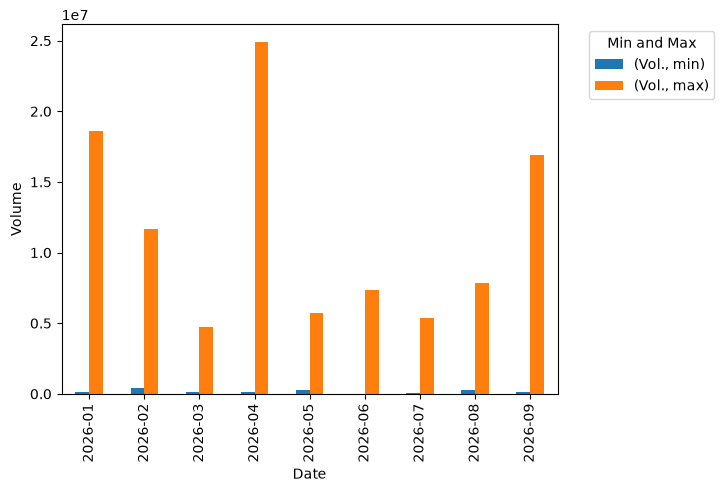

In [29]:
resultvol.plot(kind = 'bar')

plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend(title = 'Min and Max', bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.show()

## Insight
### Reached it's maximum volume in the month of april and it's least maximum volume the month before. So the price is expected to increase immediately before during or immediately after.

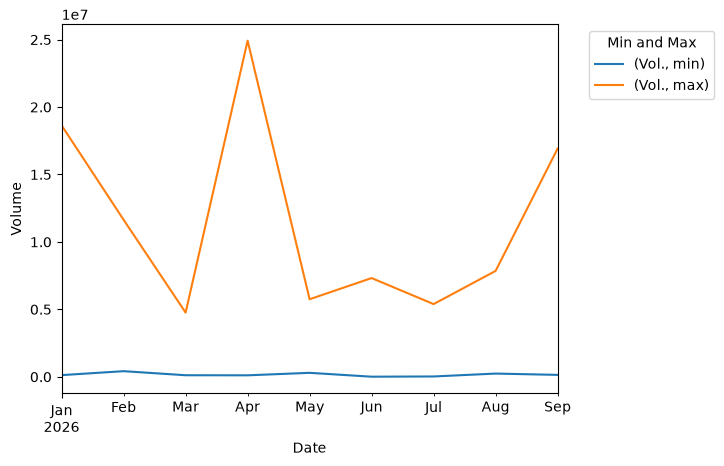

In [39]:
resultvol.plot(kind = 'line')

plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend(title = 'Min and Max', bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.show()

In [34]:
resultprice =  df.groupby(result).agg({
    'Price' : ['min', 'max']
})
resultprice

Price      
           min   max
Date                
2026-01  41.90  50.0
2026-02  43.00  51.9
2026-03  45.00  48.0
2026-04  46.00  80.6
2026-05  80.65  97.4
2026-06  95.20  97.4
2026-07  85.70  95.2
2026-08  64.95  80.1
2026-09  66.00  74.0

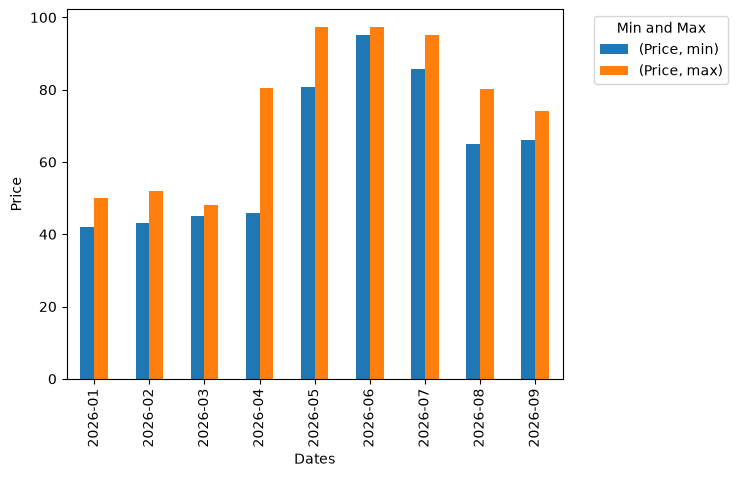

In [37]:
resultprice.plot(kind = 'bar')

plt.xlabel('Dates')
plt.ylabel('Price')
plt.legend(title = 'Min and Max', bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.show()

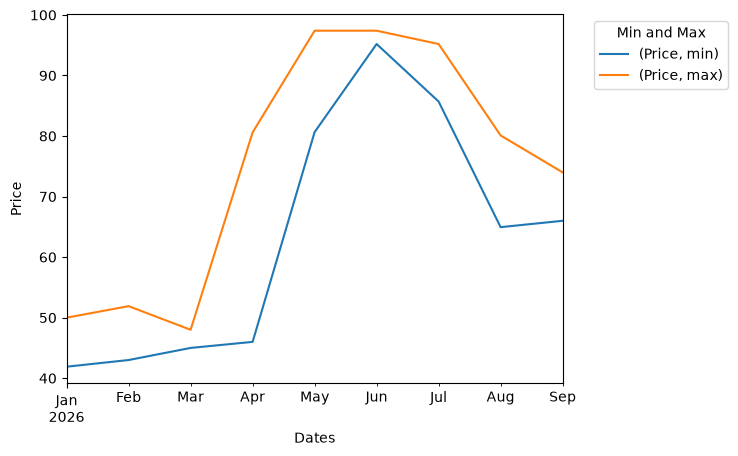

In [38]:
resultprice.plot(kind = 'line')

plt.xlabel('Dates')
plt.ylabel('Price')
plt.legend(title = 'Min and Max', bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.show()